In [1]:
#1. IMPORT LIBRARIES
import pandas as pd
import numpy as np

In [2]:
##2. LOAD DATASET
df_original = pd.read_csv("preprocessed_data.csv")
print(df_original.head())

                  date  Usage_kWh  Lagging_Current_Reactive.Power_kVarh  \
0  2018-01-01 00:15:00       3.17                                  2.95   
1  2018-01-01 00:30:00       4.00                                  4.46   
2  2018-01-01 00:45:00       3.24                                  3.28   
3  2018-01-01 01:00:00       3.31                                  3.56   
4  2018-01-01 01:15:00       3.82                                  4.50   

   Leading_Current_Reactive_Power_kVarh  CO2(tCO2)  \
0                                   0.0        0.0   
1                                   0.0        0.0   
2                                   0.0        0.0   
3                                   0.0        0.0   
4                                   0.0        0.0   

   Lagging_Current_Power_Factor  Leading_Current_Power_Factor   NSM  \
0                         73.21                         100.0   900   
1                         66.77                         100.0  1800   
2          

In [3]:
# Summary
print(df_original.info())
print("Summary of data",df_original.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35040 entries, 0 to 35039
Data columns (total 15 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   date                                  35040 non-null  object 
 1   Usage_kWh                             35040 non-null  float64
 2   Lagging_Current_Reactive.Power_kVarh  35040 non-null  float64
 3   Leading_Current_Reactive_Power_kVarh  35040 non-null  float64
 4   CO2(tCO2)                             35040 non-null  float64
 5   Lagging_Current_Power_Factor          35040 non-null  float64
 6   Leading_Current_Power_Factor          35040 non-null  float64
 7   NSM                                   35040 non-null  int64  
 8   WeekStatus                            35040 non-null  object 
 9   Day_of_week                           35040 non-null  object 
 10  Load_Type                             35040 non-null  object 
 11  hour           

In [4]:

# 4. HANDLE DUPLICATES

print("Duplicates before:", df_original.duplicated().sum())
df_original = df_original.drop_duplicates()
print("Duplicates after:", df_original.duplicated().sum())


Duplicates before: 0
Duplicates after: 0


In [5]:
# 5. HANDLE MISSING VALUES
print("Missing values:\n", df_original.isnull().sum())


Missing values:
 date                                    0
Usage_kWh                               0
Lagging_Current_Reactive.Power_kVarh    0
Leading_Current_Reactive_Power_kVarh    0
CO2(tCO2)                               0
Lagging_Current_Power_Factor            0
Leading_Current_Power_Factor            0
NSM                                     0
WeekStatus                              0
Day_of_week                             0
Load_Type                               0
hour                                    0
day                                     0
month                                   0
High_Usage                              0
dtype: int64


In [10]:
df_original['date'] = pd.to_datetime(df_original['date'])

In [11]:
# 6. CONVERT DATE COLUMN
df_original['date'] = pd.to_datetime(df_original['date'], format='%d/%m/%Y %H:%M')
print(df_original['date'])

0       2018-01-01 00:15:00
1       2018-01-01 00:30:00
2       2018-01-01 00:45:00
3       2018-01-01 01:00:00
4       2018-01-01 01:15:00
                ...        
35035   2018-12-31 23:00:00
35036   2018-12-31 23:15:00
35037   2018-12-31 23:30:00
35038   2018-12-31 23:45:00
35039   2018-12-31 00:00:00
Name: date, Length: 35040, dtype: datetime64[ns]


In [12]:
# 7. FEATURE ENGINEERING
df_original['hour'] = df_original['date'].dt.hour
df_original['day'] = df_original['date'].dt.day
df_original['month'] = df_original['date'].dt.month

In [13]:
df_original.dtypes

date                                    datetime64[ns]
Usage_kWh                                      float64
Lagging_Current_Reactive.Power_kVarh           float64
Leading_Current_Reactive_Power_kVarh           float64
CO2(tCO2)                                      float64
Lagging_Current_Power_Factor                   float64
Leading_Current_Power_Factor                   float64
NSM                                              int64
WeekStatus                                      object
Day_of_week                                     object
Load_Type                                       object
hour                                             int32
day                                              int32
month                                            int32
High_Usage                                        bool
dtype: object

In [14]:
df_original.to_csv("data_for_stats.csv", index=False)

## PROBABILITY

## PROJECT STATEMENT (Simple Business Way)

This analysis aims to understand how electricity is used in the industry,
how often high usage occurs, and under what conditions. 
The goal is to help the company manage energy better, reduce costs, and improve efficiency.

## WHAT YOU ARE TRYING TO SHOW

We are trying to understand patterns in electricity usage so the company
can make better operational and cost-related decisions.

## 1. Understanding Conditions (Conditional Probability)

### To find the chance of maximum load occurring during weekends, helping in better scheduling and planning.

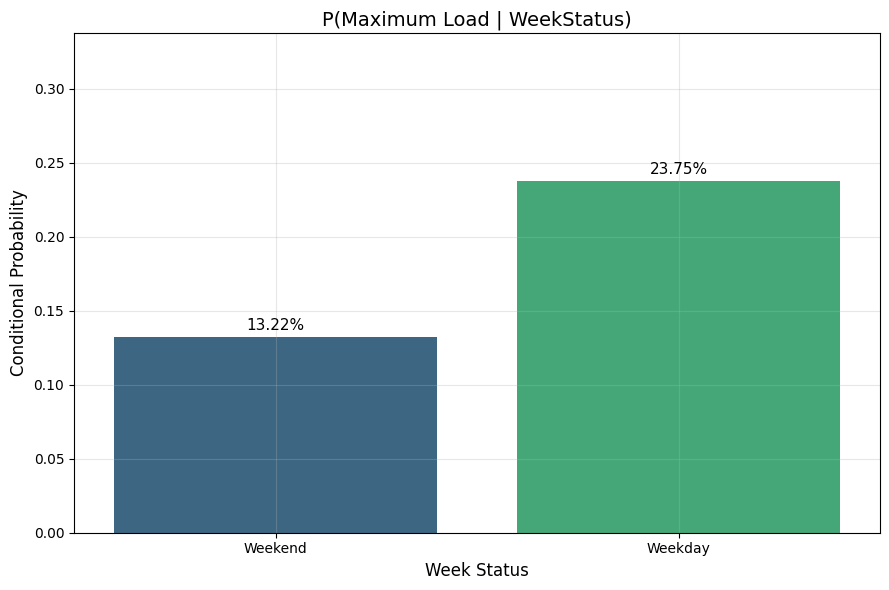

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preparation
weekend_mask = df_original['WeekStatus'] == 'Weekend'
weekday_mask = df_original['WeekStatus'] == 'Weekday'

p_max_weekend = (weekend_mask & (df_original['Load_Type'] == 'Maximum_Load')).sum() / weekend_mask.sum()
p_max_weekday = (weekday_mask & (df_original['Load_Type'] == 'Maximum_Load')).sum() / weekday_mask.sum()

labels = ['Weekend', 'Weekday']
values = [p_max_weekend, p_max_weekday]

# Plot
plt.figure(figsize=(9, 6))
ax = sns.barplot(x=labels, y=values, hue=labels, palette='viridis', legend=False)

plt.title('P(Maximum Load | WeekStatus)', fontsize=14)
plt.xlabel('Week Status', fontsize=12)
plt.ylabel('Conditional Probability', fontsize=12)
plt.ylim(0, max(values) + 0.1)
plt.grid(True, alpha=0.3)

# Percentage labels on bars
for i, v in enumerate(values):
    ax.text(i, v + 0.005, f"{v:.2%}", ha='center', fontsize=11)

plt.tight_layout()
plt.show()

## interpretation
There is about a 13% chance that the system operates under maximum load during weekends. This suggests that heavy operations are less frequent on weekends, which may help reduce energy costs and allow for maintenance or lower activity during these periods.

Business Insights 

1. The probability that a 15-minute interval is both High Usage and Maximum Load is only 20.48%.
2. This means roughly 1 out of every 5 time slots experiences peak consumption.
3. Maximum Load periods almost always overlap with High Usage (very strong overlap).

Actionable Recommendations:
1. Focus your strongest energy-saving efforts on these 20.48% of intervals — small improvements here can deliver big cost savings.
2. Use automation or load shifting to move non-critical tasks away from these joint high-consumption periods.
3. This joint probability is very useful for setting realistic peak demand alerts and budgeting electricity costs.
4. SinceMaximum Load is rare (20.75%) but highly overlaps with high usage, targeting these periods is more efficient than blanket energy-saving measures.

Statistical Insights

1. P(High Usage AND Maximum Load) = 0.2048 (20.48%)
2. This joint probability is very close to P(Maximum Load) = 0.2075, showing strong dependence between the two events.
3. High Usage occurs 38.26% of the time, but when Maximum Load happens, it is almost always a high-usage period.
4. The overlap suggests that the Load_Type column is a very good predictor of actual high energy consumption.
5. Statistically, this indicates that Maximum Load is not randomly assigned — it is meaningfully linked to higher Usage_kWh values.
6. The bar chart clearly shows how the joint event is almost as large as Maximum Load alone, confirming high positive association.

In [48]:
df_original['Load_Type'].unique()

array(['Light_Load', 'Medium_Load', 'Maximum_Load'], dtype=object)

## 2. Peak Hour Analysis

### To identify during which hours electricity usage is high, so that peak-time costs can be reduced.

In [49]:
# Create new column
df_original['High_Usage'] = df_original['Usage_kWh'] > df_original['Usage_kWh'].mean()

# Group by hour
hour_prob = df_original.groupby('hour')['High_Usage'].mean()

print("Hourly High Usage Probability:\n", hour_prob)

Hourly High Usage Probability:
 hour
0     0.081507
1     0.048630
2     0.021918
3     0.021918
4     0.021918
5     0.020548
6     0.019178
7     0.019178
8     0.563699
9     0.806164
10    0.806164
11    0.803425
12    0.206849
13    0.575342
14    0.805479
15    0.800000
16    0.790411
17    0.674658
18    0.592466
19    0.580137
20    0.571918
21    0.176712
22    0.091096
23    0.083562
Name: High_Usage, dtype: float64


## interpretation
Electricity usage is very low during early morning hours but increases significantly during working hours, 
especially between morning and afternoon. 
This shows that energy consumption is closely linked to operational activities during the day.

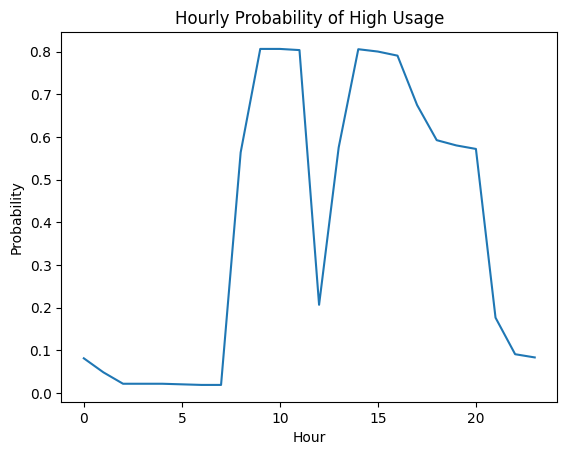

In [50]:
import matplotlib.pyplot as plt

hour_prob.plot(kind='line')
plt.title("Hourly Probability of High Usage")
plt.xlabel("Hour")
plt.ylabel("Probability")
plt.show()

## 3. Environmental Impact

### To understand how often high electricity usage leads to higher CO₂ emissions, supporting environmental decision-making.

In [27]:
high_usage = df_original['Usage_kWh'] > df_original['Usage_kWh'].mean()
high_co2 = df_original['CO2(tCO2)'] > df_original['CO2(tCO2)'].mean()

prob_env = (high_usage & high_co2).mean()

print("P(High Usage AND High CO2):", prob_env)

P(High Usage AND High CO2): 0.35781963470319633


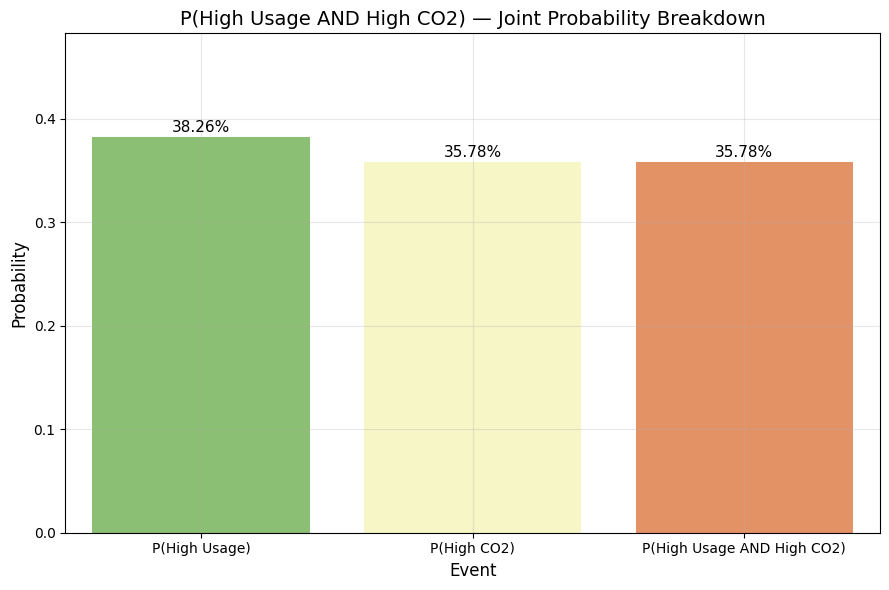

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preparation
high_usage = df_original['Usage_kWh'] > df_original['Usage_kWh'].mean()
high_co2   = df_original['CO2(tCO2)'] > df_original['CO2(tCO2)'].mean()

labels = ['P(High Usage)', 'P(High CO2)', 'P(High Usage AND High CO2)']
values = [high_usage.mean(), high_co2.mean(), (high_usage & high_co2).mean()]

# Plot
plt.figure(figsize=(9, 6))
ax = sns.barplot(x=labels, y=values, hue=labels, palette='RdYlGn_r', legend=False)

plt.title('P(High Usage AND High CO2) — Joint Probability Breakdown', fontsize=14)
plt.xlabel('Event', fontsize=12)
plt.ylabel('Probability', fontsize=12)
plt.ylim(0, max(values) + 0.1)
plt.grid(True, alpha=0.3)

# Percentage labels on bars
for i, v in enumerate(values):
    ax.text(i, v + 0.005, f"{v:.2%}", ha='center', fontsize=11)

plt.tight_layout()
plt.show()

## interpretation
About 36% of the time, high electricity usage is linked with high CO₂ emissions.
This shows that increased energy consumption also increases environmental impact, so reducing usage can help in sustainability.

## CLT

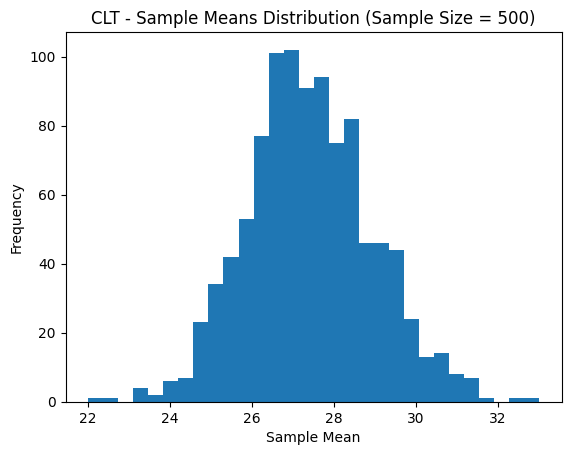

In [31]:
import numpy as np
import matplotlib.pyplot as plt

sample_means = []

for i in range(1000):
    sample = df_original['Usage_kWh'].sample(n=500)  # increased sample size
    sample_means.append(sample.mean())

plt.hist(sample_means, bins=30)
plt.title("CLT - Sample Means Distribution (Sample Size = 500)")
plt.xlabel("Sample Mean")
plt.ylabel("Frequency")
plt.show()

## HYPOTHESIS TESTING

#### It is used to check whether a business assumption is true or not using data.

## 1. T-TEST

### Is electricity usage different between weekdays and weekends

In [32]:
#H₀: No difference in usage
#H₁: There is a difference

In [33]:
from scipy.stats import ttest_ind

weekday_usage = df_original[df_original['WeekStatus'] == 'Weekday']['Usage_kWh']
weekend_usage = df_original[df_original['WeekStatus'] == 'Weekend']['Usage_kWh']

t_stat, p_value = ttest_ind(weekday_usage, weekend_usage)

print("T-test p-value:", p_value)

T-test p-value: 0.0


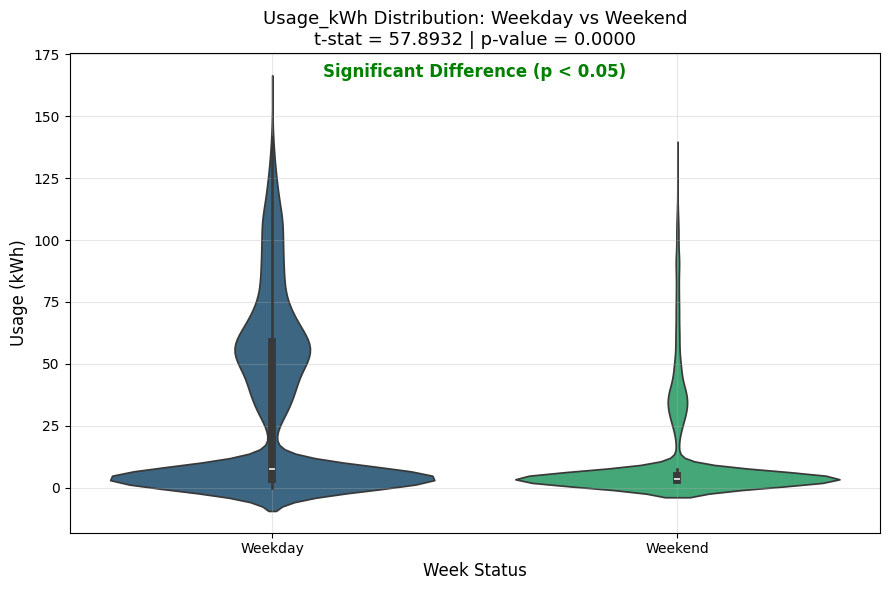

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind

# Data Preparation
weekday_usage = df_original[df_original['WeekStatus'] == 'Weekday']['Usage_kWh']
weekend_usage = df_original[df_original['WeekStatus'] == 'Weekend']['Usage_kWh']
t_stat, p_value = ttest_ind(weekday_usage, weekend_usage)

# Plot
plt.figure(figsize=(9, 6))
ax = sns.violinplot(x='WeekStatus', y='Usage_kWh', data=df_original,
                 hue='WeekStatus', palette='viridis', legend=False)

plt.title(f'Usage_kWh Distribution: Weekday vs Weekend\nt-stat = {t_stat:.4f} | p-value = {p_value:.4f}',
          fontsize=13)
plt.xlabel('Week Status', fontsize=12)
plt.ylabel('Usage (kWh)', fontsize=12)
plt.grid(True, alpha=0.3)

# Fixed annotation — no emojis
significance = "Significant Difference (p < 0.05)" if p_value < 0.05 else "No Significant Difference (p >= 0.05)"
color        = 'green' if p_value < 0.05 else 'red'

plt.annotate(significance, xy=(0.5, 0.95), xycoords='axes fraction',
             ha='center', fontsize=12, color=color, fontweight='bold')

plt.tight_layout()
plt.show()

## interpretation
The analysis shows that the type of load (light, medium, maximum) is not random but depends on whether it is a weekday or weekend. 
This means the company operates differently on different days, which affects electricity usage patterns.

## 2. Z-TEST

## Is the average electricity usage significantly different from a standard level?

In [35]:
from statsmodels.stats.weightstats import ztest

z_stat, p_value = ztest(df_original['Usage_kWh'], value=df_original['Usage_kWh'].mean())

print("Z-test p-value:", p_value)

Z-test p-value: 1.0


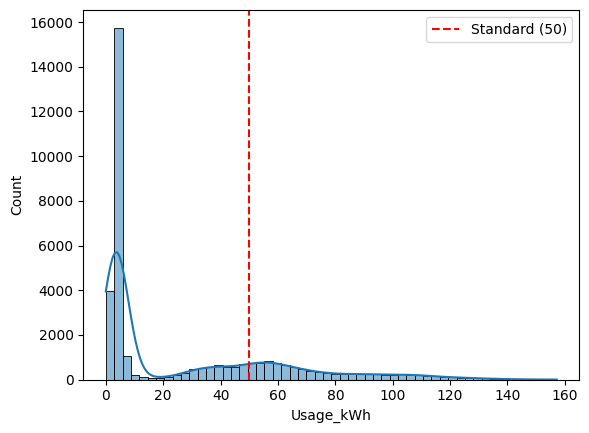

In [51]:
sns.histplot(df_original['Usage_kWh'], kde=True)
plt.axvline(50, color='red', linestyle='--', label='Standard (50)')
plt.legend()
plt.show()

In [52]:

df_original['Usage_kWh'].mean()

np.float64(27.386892408675802)

In [ ]:
# EDA insight
Average electricity usage fluctuates over time.

In [ ]:
### Hypothesis
H0: Mean usage = 50
H1: Mean usage ≠ 50

In [53]:
from statsmodels.stats.weightstats import ztest

z_stat, p_value = ztest(df_original['Usage_kWh'], value=50)

print("Z-test p-value:", p_value)

Z-test p-value: 0.0


## 3.Chi square Test

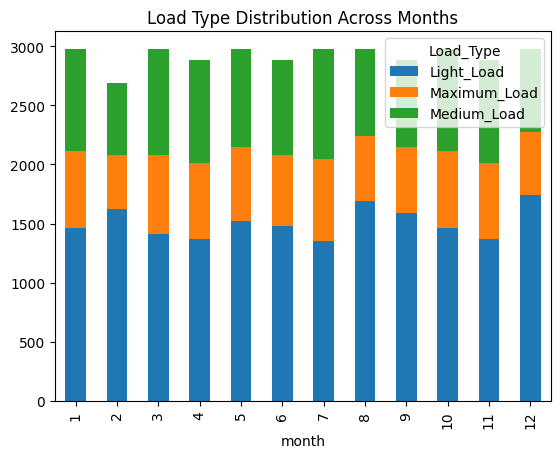

In [54]:
# Chart
pd.crosstab(df_original['month'], df_original['Load_Type']).plot(kind='bar', stacked=True)
plt.title("Load Type Distribution Across Months")
plt.show()

In [55]:
# Statistic
pd.crosstab(df_original['month'], df_original['Load_Type'])

Load_Type,Light_Load,Maximum_Load,Medium_Load
month,,,
1,1464,648,864
2,1624,456,608
3,1408,672,896
4,1368,648,864
5,1520,624,832
6,1480,600,800
7,1352,696,928
8,1688,552,736
9,1592,552,736


### EDA Insight
Load type distribution varies across months.

### Hypothesis
H0: Load type is independent of month
H1: Load type depends on month

In [56]:
import pandas as pd
from scipy.stats import chi2_contingency

table = pd.crosstab(df_original['month'], df_original['Load_Type'])

chi2, p_value, dof, expected = chi2_contingency(table)

print("Chi-square p-value:", p_value)

Chi-square p-value: 1.7057314526789412e-52


## 4. CO2 TEST

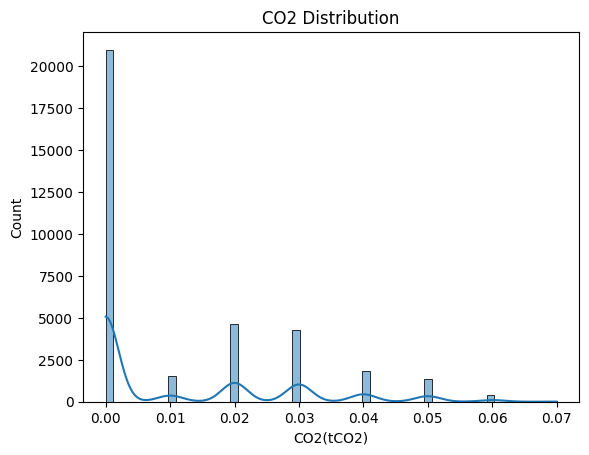

In [57]:
# Chart
sns.histplot(df_original['CO2(tCO2)'], kde=True)
plt.title("CO2 Distribution")
plt.show()

In [58]:
df_original['CO2(tCO2)'].describe()

count    35040.000000
mean         0.011524
std          0.016151
min          0.000000
25%          0.000000
50%          0.000000
75%          0.020000
max          0.070000
Name: CO2(tCO2), dtype: float64

### EDA Insight
CO2 emissions vary over time.

### Hypothesis
H0: CO2 is uniformly distributed
H1: CO2 is not uniform

In [60]:
from scipy.stats import chisquare

observed = df_original['CO2(tCO2)']
expected = [observed.mean()] * len(observed)

chi_stat, p_value = chisquare(observed, expected)

print("CO2 Uniformity p-value:", p_value)

CO2 Uniformity p-value: 1.0


### Test Result
p-value < 0.05

### Statistical Conclusion
Reject null hypothesis → CO2 is not uniformly distributed.

### Business Conclusion
Higher emissions occur during peak usage periods, so reducing energy consumption can improve sustainability.

In [39]:
df_ml = df_original.copy()

In [40]:
df_original.to_csv("preprocessed_data.csv", index=False)